# RETFound → Diabetic Retinopathy fine-tuning (per-eye labels)

Fine-tunes the **RETFound colour-fundus** foundation model (`RETFound_mae_natureCFP`,
ViT-Large) to grade diabetic retinopathy on a local Tanzanian screening dataset.

This notebook is the training+evaluation front-end. Phases 0–3 (data audit, manifest,
patient-level split, ImageFolder) were produced by the scripts in `pipeline/` and are
summarised in **`DATA_REPORT.md`**. Re-run them with the first code cell if needed.

### Verified laterality mapping (the one thing that silently inverts every label)
- CSV (`Reading_Grades.xlsx`, **Sheet2**, one row/patient) labels each eye by explicit
  column name: **`Retinopathy (Left Eye)` → LE**, **`Retinopathy (Right Eye)` → RE**.
- Image filenames encode the eye by token `_LE_/_RE_/_OD_/_OS_`, with the standard
  ophthalmic convention **OD (dexter)=RIGHT=RE, OS (sinister)=LEFT=LE**, independently
  confirmed by patient `2406` (its `RE/` folder holds `_OD_` files, `LE/` holds `_OS_`).
- Images whose folder and filename disagree on laterality (798) are **excluded** (ambiguous eye).

### Task & label scheme (justified in DATA_REPORT.md §6)
- **4-class ordinal** NHS-DESP grade **R0/R1/R2/R3** (R3A+R3S→R3; `U`=ungradable excluded).
- Class→index: `R0_no_dr=0, R1_mild=1, R2_moderate_severe=2, R3_proliferative=3`.
- **Selection metric = validation quadratic-weighted Cohen's kappa (QWK)** — *not accuracy*.
- The binary **referable-DR (R2+)** view is derived from the same head at evaluation.

Usable data: **8407 images / 3834 eyes / 2194 patients**; patient-level 70/15/15 split.

## ⚠️ Gated model access — do this once before running

`RETFound_mae_natureCFP` is a **gated** Hugging Face model. You must:

1. Open <https://huggingface.co/YukunZhou/RETFound_mae_natureCFP> and **accept the access form**.
2. Authenticate in this environment (token from <https://huggingface.co/settings/tokens>):
   ```bash
   huggingface-cli login --token <YOUR_HF_TOKEN>
   ```
   *(A subagent/assistant cannot complete the gated form for you — this step is manual.)*
3. If Hugging Face is unreachable from your network, set a mirror **before** the import cell:
   ```python
   import os; os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
   ```

The download is triggered in the **“Build model”** cell (`hf_hub_download`). A 403
`GatedRepoError` there means step 1 or 2 is incomplete.

In [1]:
# --- (optional) rebuild Phases 0-3 from scratch. Skips if the ImageFolder already exists. ---
import os, subprocess, sys
PROJECT = os.path.abspath(".")
assert os.path.isdir("pipeline"), "Run this notebook from the project root (Retfound.V2/)."
if not os.path.isdir("outputs/dr_imagefolder"):
    for script in ["build_manifest.py", "make_split.py", "materialize_imagefolder.py"]:
        print("running", script); subprocess.run([sys.executable, f"pipeline/{script}"], check=True)
# speed cache: resize the 12MP JPEGs to shorter-side 512 once (~30x faster decode per epoch)
if not os.path.isdir("outputs/dr_imagefolder_cache"):
    print("building resize speed-cache (one-time, a few minutes)...")
    subprocess.run([sys.executable, "pipeline/build_resized_cache.py", "--size", "512"], check=True)
# clone RETFound if missing + install its requirements
if not os.path.isdir("RETFound_repo"):
    subprocess.run(["git","clone","--depth","1","https://github.com/rmaphoh/RETFound.git","RETFound_repo"], check=True)
    subprocess.run([sys.executable,"-m","pip","install","-q","-r","RETFound_repo/requirements.txt"], check=True)
print("ready")

ready


In [2]:
# ============================ CONFIG (all knobs here) ============================
CONFIG = dict(
    # data / model
    data_path   = "outputs/dr_imagefolder_cache",  # resized (short-side 512) speed cache;
                                               # use "outputs/dr_imagefolder" for full-res symlinks

    nb_classes  = 4,                            # R0,R1,R2,R3 ordinal
    input_size  = 224,                          # RETFound CFP native
    finetune_id = "RETFound_mae_natureCFP",     # GATED colour-fundus weights (NOT OCT)
    drop_path   = 0.2,

    # adaptation strategy: FULL fine-tune (justified: ~3.8k eyes / ~5.8k train imgs exceeds
    # RETFound's own downstream benchmarks IDRiD/MESSIDOR/APTOS, all full fine-tuned).
    adaptation  = "finetune",                   # "finetune" (full) or "lp" (linear probe)

    # optimisation (RETFound recipe)
    batch_size    = 16,     # A4000 16GB: peaks ~7GB @224; raise on bigger GPUs
    accum_iter    = 4,      # effective batch = 16*4 = 64
    epochs        = 50,
    warmup_epochs = 10,
    blr           = 5e-3,   # lr = blr * eff_batch/256  -> 1.25e-3
    layer_decay   = 0.65,   # layer-wise LR decay (imported from util.lr_decay)
    weight_decay  = 0.05,
    min_lr        = 1e-6,
    clip_grad     = None,

    # class-imbalance: inverse-frequency WEIGHTED cross-entropy (mixup is OFF in this
    # recipe, so soft-target issues don't arise). See class weights printed below.
    # (Alternative WeightedRandomSampler noted in DATA_REPORT.md; weighted-CE chosen for simplicity.)

    # runtime
    device      = "cuda",
    seed        = 42,
    num_workers = 10,
    output_dir  = "outputs/train_run",
    task        = "dr_retfound_r0r3",
)
SELECTION_METRIC = "qwk"   # validation quadratic-weighted kappa -> best checkpoint
import os; os.makedirs(CONFIG["output_dir"], exist_ok=True)
CONFIG

{'data_path': 'outputs/dr_imagefolder_cache',
 'nb_classes': 4,
 'input_size': 224,
 'finetune_id': 'RETFound_mae_natureCFP',
 'drop_path': 0.2,
 'adaptation': 'finetune',
 'batch_size': 16,
 'accum_iter': 4,
 'epochs': 50,
 'warmup_epochs': 10,
 'blr': 0.005,
 'layer_decay': 0.65,
 'weight_decay': 0.05,
 'min_lr': 1e-06,
 'clip_grad': None,
 'device': 'cuda',
 'seed': 42,
 'num_workers': 10,
 'output_dir': 'outputs/train_run',
 'task': 'dr_retfound_r0r3'}

In [3]:
# ============================ imports, seeds, device ============================
import os, sys, json, time, copy
import numpy as np, torch
sys.path.insert(0, "pipeline"); sys.path.insert(0, "RETFound_repo")

import dr_train as T          # thin wrappers that IMPORT RETFound's real code
import dr_eval as E           # Phase-5 metrics / aggregation
from engine_finetune import train_one_epoch          # RETFound's train loop (imported, not reimplemented)

args = T.make_args(CONFIG)
T.set_seed(CONFIG["seed"])
torch.backends.cudnn.benchmark = True
device = torch.device(CONFIG["device"] if torch.cuda.is_available() else "cpu")
print("device:", device, "| torch", torch.__version__)

/home/eth/miniforge3/envs/retfound/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda | torch 2.5.1+cu121


In [4]:
# ============================ data + class weights ============================
(ds_tr, ds_va, ds_te), (dl_tr, dl_va, dl_te) = T.build_loaders(args, shuffle_train=True)
print("images  train/val/test:", len(ds_tr), len(ds_va), len(ds_te))
print("class_to_idx:", ds_tr.class_to_idx)

# sanity: the ImageFolder mapping must equal our documented class->index
import json as _json
CM = _json.load(open("outputs/class_mapping.json"))
assert ds_tr.class_to_idx == CM["ordinal_class_to_index"], "class mapping mismatch!"

class_weights, counts = T.class_weights_from_dataset(ds_tr, CONFIG["nb_classes"], device)
print("train class counts :", counts)
print("CE class weights   :", class_weights.cpu().numpy().round(3))

images  train/val/test: 5853 1268 1286
class_to_idx: {'R0_no_dr': 0, 'R1_mild': 1, 'R2_moderate_severe': 2, 'R3_proliferative': 3}
train class counts : [3369 1909  299  276]
CE class weights   : [0.152 0.269 1.718 1.861]


In [5]:
# ============================ build model + load GATED weights ============================
model = T.build_model_arch(args)                      # ViT-L via models_vit (global_pool)
msg = T.load_pretrained(model, args)                  # hf_hub_download + interpolate_pos_embed + strict=False
model.to(device)
# expected missing = the freshly-initialised classifier head + global-pool norm
# (head.weight/bias, fc_norm.weight/bias). Unexpected = MAE decoder keys, correctly dropped.
print("missing keys (expect head.* + fc_norm.*):", list(msg.missing_keys))
print(f"unexpected keys: {len(msg.unexpected_keys)} (MAE decoder / replaced encoder norm — discarded)")
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable params: {n_train/1e6:.1f} M  | adaptation={args.adaptation}")

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_train.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location="cpu")


missing keys (expect head.* + fc_norm.*): ['fc_norm.weight', 'fc_norm.bias', 'head.weight', 'head.bias']
unexpected keys: 106 (MAE decoder / replaced encoder norm — discarded)
trainable params: 303.3 M  | adaptation=finetune


In [6]:
# ============================ optimizer / criterion / scaler ============================
optimizer, loss_scaler = T.build_optimizer(model, args)    # param_groups_lrd + AdamW + AMP scaler
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
print(f"param groups: {len(optimizer.param_groups)} | base lr: {args.lr:.2e} | eff batch: {args.batch_size*args.accum_iter}")
print("criterion:", criterion)

param groups: 52 | base lr: 1.25e-03 | eff batch: 64
criterion: CrossEntropyLoss()


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/util/misc.py:249: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler()


In [7]:
# ============================ training loop (select best by val QWK) ============================
from sklearn.metrics import cohen_kappa_score, roc_auc_score

def val_scores():
    y, p = E.predict(model, dl_va, device)
    pred = p.argmax(1)
    qwk = cohen_kappa_score(y, pred, weights="quadratic", labels=list(range(CONFIG["nb_classes"])))
    try:
        yoh = np.eye(CONFIG["nb_classes"])[y]; cols = [c for c in range(CONFIG["nb_classes"]) if yoh[:,c].sum()>0]
        auroc = roc_auc_score(yoh[:,cols], p[:,cols], average="macro", multi_class="ovr")
    except Exception: auroc = float("nan")
    msens, mspec = E.macro_sens_spec(y, pred)   # macro sensitivity / specificity
    return float(qwk), float(auroc), msens, mspec

best_score, best_epoch, best_state, history = -1.0, -1, None, []
ckpt_path = os.path.join(CONFIG["output_dir"], "checkpoint-best.pth")
t0 = time.time()
for epoch in range(CONFIG["epochs"]):
    tr = train_one_epoch(model, criterion, dl_tr, optimizer, device, epoch,
                         loss_scaler, args.clip_grad, None, None, args)
    qwk, auroc, msens, mspec = val_scores()
    score = qwk if SELECTION_METRIC == "qwk" else auroc
    history.append({"epoch": epoch, "train_loss": tr["loss"], "val_qwk": qwk,
                    "val_macro_auroc": auroc, "val_macro_sensitivity": msens,
                    "val_macro_specificity": mspec})
    tag = ""
    if score > best_score:
        best_score, best_epoch = score, epoch
        best_state = copy.deepcopy(model.state_dict())
        torch.save({"model": best_state, "epoch": epoch, "config": CONFIG, "val_qwk": qwk,
                    "val_macro_auroc": auroc, "val_macro_sensitivity": msens,
                    "val_macro_specificity": mspec}, ckpt_path)
        tag = "  <-- best"
    print(f"epoch {epoch:02d}  train_loss={tr['loss']:.4f}  val_QWK={qwk:.4f}  "
          f"val_AUROC={auroc:.4f}  val_mSens={msens:.4f}  val_mSpec={mspec:.4f}{tag}")
json.dump(history, open(os.path.join(CONFIG["output_dir"], "history.json"), "w"), indent=2)
print(f"\nDone in {(time.time()-t0)/60:.1f} min. Best epoch {best_epoch}  {SELECTION_METRIC}={best_score:.4f}")

/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [0]  [  0/365]  eta: 0:04:54  lr: 0.000000  loss: 1.3864 (1.3864)  time: 0.8075  data: 0.2410  max mem: 4509
Epoch: [0]  [ 20/365]  eta: 0:01:23  lr: 0.000007  loss: 1.3863 (1.3864)  time: 0.2148  data: 0.0001  max mem: 7983
Epoch: [0]  [ 40/365]  eta: 0:01:15  lr: 0.000014  loss: 1.3862 (1.3860)  time: 0.2193  data: 0.0001  max mem: 7983
Epoch: [0]  [ 60/365]  eta: 0:01:09  lr: 0.000021  loss: 1.3870 (1.3859)  time: 0.2241  data: 0.0001  max mem: 7983
Epoch: [0]  [ 80/365]  eta: 0:01:05  lr: 0.000027  loss: 1.3867 (1.3855)  time: 0.2261  data: 0.0001  max mem: 7983
Epoch: [0]  [100/365]  eta: 0:01:00  lr: 0.000034  loss: 1.3787 (1.3838)  time: 0.2267  data: 0.0001  max mem: 7983
Epoch: [0]  [120/365]  eta: 0:00:55  lr: 0.000041  loss: 1.3898 (1.3844)  time: 0.2273  data: 0.0001  max mem: 7983
Epoch: [0]  [140/365]  eta: 0:00:51  lr: 0.000048  loss: 1.3721 (1.3818)  time: 0.2279  data: 0.0001  max mem: 7983
Epoch: [0]  [160/365]  eta: 0:00:46  lr: 0.000055  loss: 1.3820 (1.3827)

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):


epoch 00  train_loss=1.3751  val_QWK=0.3331  val_AUROC=0.6957  val_mSens=0.3356  val_mSpec=0.8186  <-- best


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

epoch 48  train_loss=0.8399  val_QWK=0.7166  val_AUROC=0.8888  val_mSens=0.6795  val_mSpec=0.8891


/home/eth/Desktop/isaack/Retfound.V2/RETFound_repo/engine_finetune.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch: [49]  [  0/365]  eta: 0:02:56  lr: 0.000003  loss: 0.6509 (0.6509)  time: 0.4831  data: 0.2785  max mem: 9141
Epoch: [49]  [ 20/365]  eta: 0:01:24  lr: 0.000003  loss: 0.7519 (0.8097)  time: 0.2323  data: 0.0001  max mem: 9141
Epoch: [49]  [ 40/365]  eta: 0:01:18  lr: 0.000003  loss: 0.7523 (0.8118)  time: 0.2364  data: 0.0001  max mem: 9141
Epoch: [49]  [ 60/365]  eta: 0:01:12  lr: 0.000002  loss: 0.8119 (0.8260)  time: 0.2362  data: 0.0001  max mem: 9141
Epoch: [49]  [ 80/365]  eta: 0:01:07  lr: 0.000002  loss: 0.7876 (0.8365)  time: 0.2357  data: 0.0001  max mem: 9141
Epoch: [49]  [100/365]  eta: 0:01:02  lr: 0.000002  loss: 0.8297 (0.8307)  time: 0.2353  data: 0.0001  max mem: 9141
Epoch: [49]  [120/365]  eta: 0:00:58  lr: 0.000002  loss: 0.8363 (0.8376)  time: 0.2351  data: 0.0001  max mem: 9141
Epoch: [49]  [140/365]  eta: 0:00:53  lr: 0.000002  loss: 0.7747 (0.8390)  time: 0.2346  data: 0.0001  max mem: 9141
Epoch: [49]  [160/365]  eta: 0:00:48  lr: 0.000002  loss: 0.9140

/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):


epoch 49  train_loss=0.8555  val_QWK=0.7168  val_AUROC=0.8886  val_mSens=0.6826  val_mSpec=0.8891

Done in 75.6 min. Best epoch 40  qwk=0.7366


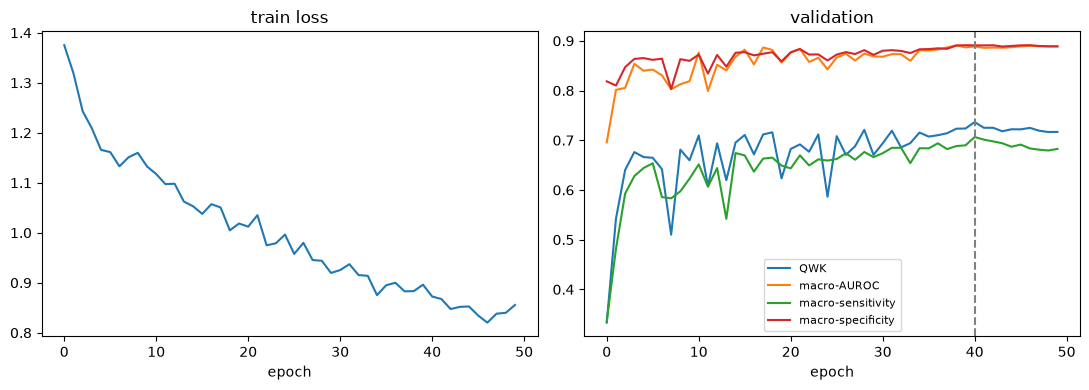

In [8]:
# ---- training curves ----
import matplotlib.pyplot as plt
h = history
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot([x["epoch"] for x in h], [x["train_loss"] for x in h]); ax[0].set_title("train loss"); ax[0].set_xlabel("epoch")
ep = [x["epoch"] for x in h]
ax[1].plot(ep, [x["val_qwk"] for x in h], label="QWK")
ax[1].plot(ep, [x["val_macro_auroc"] for x in h], label="macro-AUROC")
ax[1].plot(ep, [x["val_macro_sensitivity"] for x in h], label="macro-sensitivity")
ax[1].plot(ep, [x["val_macro_specificity"] for x in h], label="macro-specificity")
ax[1].axvline(best_epoch, ls="--", c="grey"); ax[1].legend(fontsize=8); ax[1].set_title("validation"); ax[1].set_xlabel("epoch")
fig.tight_layout(); plt.show()

## Phase 5 — Evaluation on the held-out **test** split

Loads the best checkpoint (selected by validation QWK) and reports, at **image**,
**eye** (primary), and **patient** (worst-eye) level:
- Ordinal: **QWK**, macro-AUROC (OvR), macro-AUPRC, per-class sensitivity/specificity, confusion matrix.
- Binary **referable DR (R2+)**: AUROC, AUPRC, sensitivity & specificity at a stated operating point.

Metrics saved to `outputs/train_run/eval_test/metrics.json`; ROC/PR + confusion plots saved alongside.

In [9]:
# ============================ evaluate on TEST ============================
best = torch.load(ckpt_path, map_location="cpu")
model.load_state_dict(best["model"]); model.to(device)
print(f"Loaded best checkpoint: epoch {best['epoch']}  val_QWK={best.get('val_qwk'):.4f}")

test_paths = [p for p, _ in ds_te.samples]
y_true, y_prob = E.predict(model, dl_te, device)
eval_dir = os.path.join(CONFIG["output_dir"], "eval_test")
report = E.full_report(test_paths, y_true, y_prob, eval_dir)

def show(level):
    r = report[level]; b = r["binary_referable"]
    print(f"\n===== {level.upper()} (n={r['n']}) =====")
    print(f"  QWK={r['qwk']:.4f}  macroAUROC={r['macro_auroc_ovr']:.4f}  macroAUPRC={r['macro_auprc']:.4f}  "
          f"macroF1={r['macro_f1']:.4f}  acc={r['accuracy']:.4f}")
    print(f"  macro sensitivity={r['macro_sensitivity']:.4f}  macro specificity={r['macro_specificity']:.4f}")
    print("  per-class sens/spec:", {k: (round(v['sensitivity'],3), round(v['specificity'],3), v['support'])
                                     for k, v in r['per_class'].items()})
    if "auroc" in b:
        print(f"  referable-DR: AUROC={b['auroc']:.4f}  AUPRC={b['auprc']:.4f}  "
              f"sens={b['sensitivity']:.3f}  spec={b['specificity']:.3f} @op={b['operating_point']}  (pos={b['n_pos']})")
for lv in ["image_level", "eye_level", "patient_level"]:
    show(lv)
print("\nsaved:", eval_dir)

/tmp/ipykernel_129022/3643892230.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best = torch.load(ckpt_path, map_location="cpu")


Loaded best checkpoint: epoch 40  val_QWK=0.7366


/home/eth/Desktop/isaack/Retfound.V2/pipeline/dr_eval.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=amp):



===== IMAGE_LEVEL (n=1286) =====
  QWK=0.7225  macroAUROC=0.8790  macroAUPRC=0.6556  macroF1=0.6139  acc=0.7185
  macro sensitivity=0.6537  macro specificity=0.8802
  per-class sens/spec: {0: (0.863, 0.74, 736), 1: (0.488, 0.866, 426), 2: (0.764, 0.928, 72), 3: (0.5, 0.986, 52)}
  referable-DR: AUROC=0.9625  AUPRC=0.7460  sens=0.847  spec=0.927 @op=0.5  (pos=124)

===== EYE_LEVEL (n=584) =====
  QWK=0.7454  macroAUROC=0.8879  macroAUPRC=0.6728  macroF1=0.6161  acc=0.7380
  macro sensitivity=0.6566  macro specificity=0.8896
  per-class sens/spec: {0: (0.88, 0.761, 333), 1: (0.521, 0.885, 194), 2: (0.771, 0.931, 35), 3: (0.455, 0.982, 22)}
  referable-DR: AUROC=0.9651  AUPRC=0.7493  sens=0.895  spec=0.937 @op=0.5  (pos=57)

===== PATIENT_LEVEL (n=330) =====
  QWK=0.7799  macroAUROC=0.8805  macroAUPRC=0.6456  macroF1=0.6010  acc=0.7212
  macro sensitivity=0.6304  macro specificity=0.8907
  per-class sens/spec: {0: (0.879, 0.795, 174), 1: (0.542, 0.877, 118), 2: (0.6, 0.913, 20), 3: (0.5,

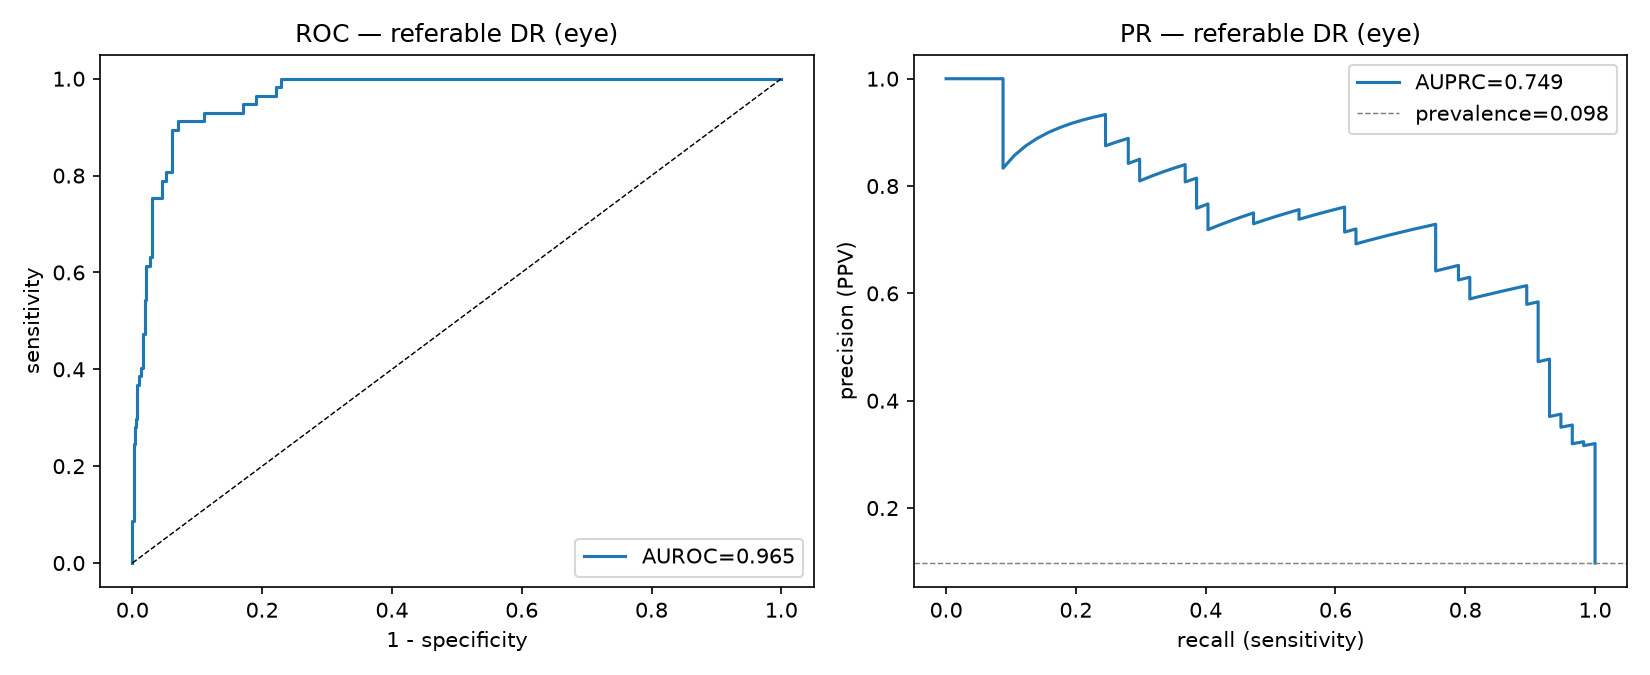

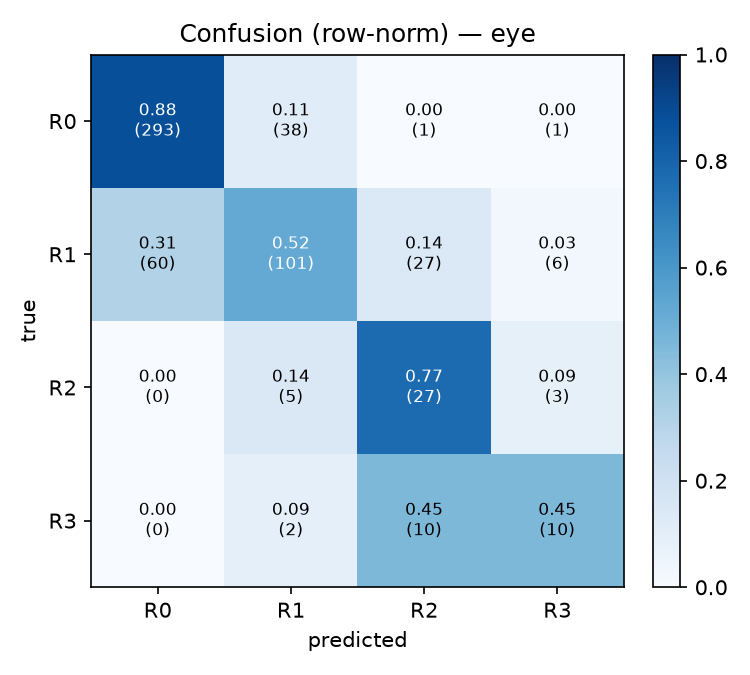

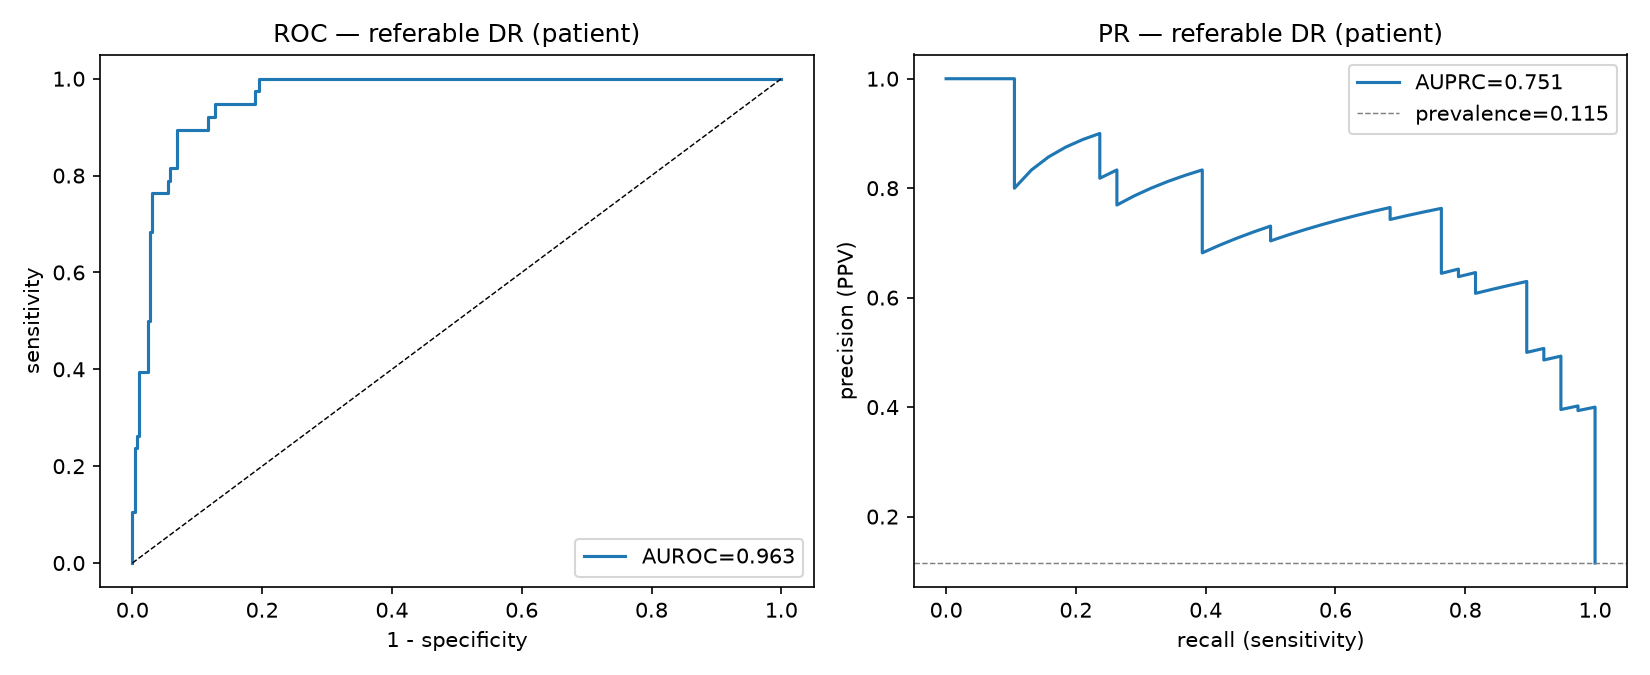

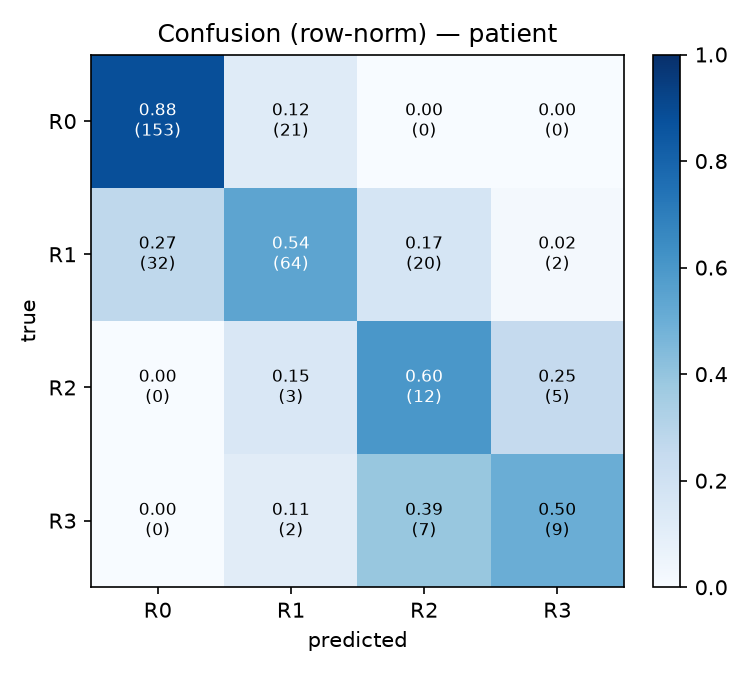

In [10]:
# ---- show saved plots ----
from IPython.display import Image, display
for f in ["roc_pr_eye.png", "confusion_eye.png", "roc_pr_patient.png", "confusion_patient.png"]:
    p = os.path.join(eval_dir, f)
    if os.path.exists(p): display(Image(p))

## Honest reporting notes
- **Minority classes are small** at eye level (test ≈ 35 R2, 22 R3 eyes). QWK / per-class
  sensitivity for R2–R3 and the referable-DR PR curve are estimated on few positives —
  treat single numbers as indicative, not settled. Prefer the ranges you'd get from
  **k-fold CV** if a firm estimate is needed (recommended before any deployment claim).
- **Lead with AUPRC + sensitivity** for referable DR (prevalence ≈ 10 %); accuracy is
  reported only as a secondary descriptor.
- **798 laterality-discordant images were excluded**, not silently relabeled; trusting the
  filename token instead would recover them but risks inverted per-eye labels.
- The model selection metric is **validation QWK**, never accuracy.